In [1]:
from Utils.utils_spark import retrieve_credentials, get_access_token, list_contracts

# Input the path to your client credentials here
client_id, client_secret = retrieve_credentials(file_path="adhoc_scripts\\client_credentials.csv")

# Authenticate:
access_token = get_access_token(client_id, client_secret)
# print(access_token)
list_contracts(access_token)

>>>> Found credentials!
>>>> Client_id=d0953****, client_secret=601d8****
>>>> Successfully fetched an access token eyJhb****, valid 604799 seconds.
>>>> All the contracts you can fetch
Spark25F Pacific 160 TFDE
Spark30F Atlantic 160 TFDE
Spark25S Pacific
Spark25Fo Pacific
Spark25FFA Pacific
Spark25FFAYearly Pacific
Spark30S Atlantic
Spark30Fo Atlantic
Spark30FFA Atlantic
Spark30FFAYearly Atlantic
SparkNWE DES 1H
SparkNWE-B 1H
SparkNWE DES 2H
SparkNWE-B 2H
SparkNWE-B F
SparkNWE DES F
SparkNWE-B Fo
SparkNWE DES Fo
SparkNWE-DES-Fin Monthly
SparkNWE-Fin Monthly
SparkSWE-B F
SparkSWE DES F
SparkSWE-B Fo
SparkSWE DES Fo
SparkSWE-DES-Fin Monthly
SparkSWE-Fin Monthly


['spark25f',
 'spark30f',
 'spark25s',
 'spark25fo',
 'spark25ffa-monthly',
 'spark25ffa-yearly',
 'spark30s',
 'spark30fo',
 'spark30ffa-monthly',
 'spark30ffa-yearly',
 'sparknwe-1h',
 'sparknwe-b-1h',
 'sparknwe-2h',
 'sparknwe-b-2h',
 'sparknwe-b-f',
 'sparknwe-f',
 'sparknwe-b-fo',
 'sparknwe-fo',
 'sparknwe-des-fin-monthly',
 'sparknwe-fin-monthly',
 'sparkswe-b-f',
 'sparkswe-f',
 'sparkswe-b-fo',
 'sparkswe-fo',
 'sparkswe-des-fin-monthly',
 'sparkswe-fin-monthly']

In [9]:
from Utils.utils_spark import fetch_freight_prices

spark30_174 = fetch_freight_prices(access_token, "spark30s", 30*30, my_vessel='174-2stroke')
spark30_174

/v1.0/contracts/spark30s/price-releases/?limit=900&vessel-type=174-2stroke
Fetching https://api.sparkcommodities.com/v1.0/contracts/spark30s/price-releases/?limit=900&vessel-type=174-2stroke


,Release Date,ticker,Period Start,USDperday,USDperdayMax,USDperdayMin
0,2026-01-16,spark30s,2026-01-31,26250,28000.0,25000.0
1,2026-01-15,spark30s,2026-01-30,35000,39000.0,32000.0
2,2026-01-14,spark30s,2026-01-29,37250,39000.0,35000.0
3,2026-01-13,spark30s,2026-01-28,44500,50000.0,41250.0
4,2026-01-12,spark30s,2026-01-27,47000,50000.0,44000.0
...,...,...,...,...,...,...
895,2022-01-04,spark30s,2022-01-19,94750,NaN,NaN
896,2021-12-30,spark30s,2022-01-14,101000,NaN,NaN
897,2021-12-21,spark30s,2022-01-05,135000,NaN,NaN
898,2021-12-17,spark30s,2022-01-01,192000,NaN,NaN


,ticker,Period Start,USDperday,USDperdayMax,USDperdayMin
Release Date,,,,,
2026-01-16,spark30s,2026-01-31,26250,28000.0,25000.0
2026-01-15,spark30s,2026-01-30,35000,39000.0,32000.0
2026-01-14,spark30s,2026-01-29,37250,39000.0,35000.0
2026-01-13,spark30s,2026-01-28,44500,50000.0,41250.0
2026-01-12,spark30s,2026-01-27,47000,50000.0,44000.0
...,...,...,...,...,...
2022-01-04,spark30s,2022-01-19,94750,NaN,NaN
2021-12-30,spark30s,2022-01-14,101000,NaN,NaN
2021-12-21,spark30s,2022-01-05,135000,NaN,NaN


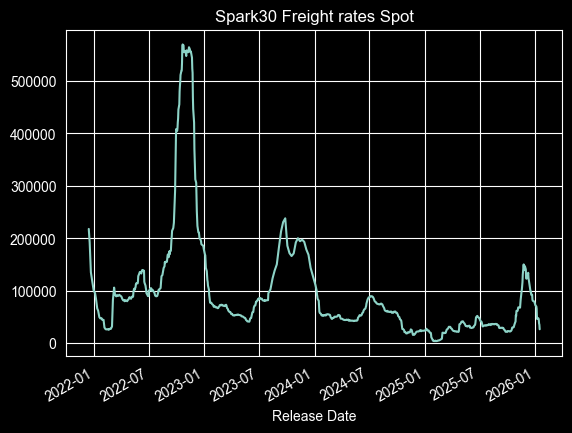

In [10]:
df = spark30_174.copy()
df.set_index("Release Date", inplace=True)
df["USDperday"].plot(title="Spark30 Freight rates Spot")
df

In [ ]:
import matplotlib.pyplot as plt
plt.hist(df["USDperday"], label="Spark30 Freight rates Spot", bins=100);

In [11]:
from Utils.utils_spark import fetch_ffa_prices

my_dict = fetch_ffa_prices(access_token, "spark30ffa-monthly", 2, latest_only=True)

spark30ffa-monthly
Fetching https://api.sparkcommodities.com/v1.0/contracts/spark30ffa-monthly/price-releases/latest/
>>>> Get latest price release for spark30ffa-monthly
release date = 2026-01-15
- release date = 2026-01-15


In [18]:
from Utils.utils_spark import fetch_ffa_prices_for_month_only
import numpy as np
month_tenor = "Apr-2027"
dict_freight_std_by_month = {}
year = 2026
for month_tenor in [m+str(year) for m in ["Feb-", "Mar-","Apr-","May-","Jun-","Jul-","Aug-","Sep-","Oct-","Nov-","Dec-"]]:
    df_month = fetch_ffa_prices_for_month_only(access_token, "spark30ffa-monthly", 30*30, month_tenor)
    logreturns = np.log(df_month.Spark / df_month.Spark.shift(-1)).dropna()
    std_month = logreturns.std()*np.sqrt(252)
    dict_freight_std_by_month[month_tenor] = std_month

print(dict_freight_std_by_month)

spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
{'Feb-2026': np.float64(0.5257224579748875), 'Mar-2026': np.float64(0.4272821154327676), 'Apr-2026': np.float64(0.35470422036485266), 'May-2026': np.float64(0.38161671240767076), 'Jun-2026': np.float64(0.3400697543366433), 'Jul-2026': np.float64(0.3253155723185065), 'Aug-2026': np.float64(0.30515660917664256), 'Sep-2026': np.float64(0.27712134963192675), 'Oct-2026': np.float64(0.33314885877716155), 'Nov-2026': np.float64(0.3194520647776239), 'Dec-2026': np.float64(0.3005430119110691)}


In [20]:
np.mean([v for v in dict_freight_std_by_month.values()])

np.float64(0.3536484297372502)

In [15]:
dict_freight_std_by_month

{'Jan-2027': np.float64(0.1436788673510875),
 'Feb-2027': np.float64(0.1596549882787137),
 'Mar-2027': np.float64(0.160393412239646),
 'Apr-2027': np.float64(0.11358911725773227),
 'May-2027': np.float64(0.0874439161666468),
 'Jun-2027': np.float64(0.07965593366104731),
 'Jul-2027': np.float64(0.07017909166209002),
 'Aug-2027': np.float64(0.0711954804313588),
 'Sep-2027': np.float64(0.06356911069866941),
 'Oct-2027': np.float64(0.07193090377417106),
 'Nov-2027': np.float64(0.11435402563484927),
 'Dec-2027': np.float64(0.1270129944468328)}

In [4]:
current_ffa_prices = {}

for month_tenor in [m+str(year) for m in ["Feb-", "Mar-","Apr-","May-","Jun-","Jul-","Aug-","Sep-","Oct-","Nov-","Dec-"]]:
    df_month = fetch_ffa_prices_for_month_only(access_token, "spark30ffa-monthly", 1, month_tenor);
    current_ffa_prices[month_tenor] = df_month.Spark.values[0].tolist()

days = {'Feb-2026': 28,
 'Mar-2026': 31,
 'Apr-2026': 30,
 'May-2026': 31,
 'Jun-2026': 30,
 'Jul-2026': 31,
 'Aug-2026': 31,
 'Sep-2026': 30,
 'Oct-2026': 31,
 'Nov-2026': 30,
 'Dec-2026': 31}


spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly


In [25]:
from datetime import date
from Pricers.european_option import black76_price

pricing_date = date(2026, 1, 16)
expiry_date = date(2026, 10, 31)
fwd_price = 51063
strike = 58000
option_type = "c"
vol = 0.15
r = 0.02
opt27_value = black76_price(
    pricing_date,
    expiry_date,
    fwd_price,
    strike,
    option_type,
    vol,
    r
) * 365

opt28_value = black76_price(
    pricing_date,
    expiry_date,
    60500,
    strike,
    option_type,
    vol,
    r
) * 30 * 8

year=2026

bleed_2026 = 0
for m in days:
    bleed_2026 += days[m] * (current_ffa_prices[m] - 40000)

print(f"2027 Freight option value in USD: {opt27_value:.2f}")
print(f"2028 Freight option value in USD: {opt28_value:.2f}")
print(f"2026 Bleeding = {bleed_2026:.2f}")

2027 Freight option value in USD: 235523.87
2028 Freight option value in USD: 1075714.65
2026 Bleeding = -1321750.00


In [54]:
current_ffa_prices

{'Feb-2026': 24000,
 'Mar-2026': 22500,
 'Apr-2026': 24000,
 'May-2026': 26500,
 'Jun-2026': 30000,
 'Jul-2026': 32250,
 'Aug-2026': 36500,
 'Sep-2026': 42500,
 'Oct-2026': 49500,
 'Nov-2026': 53750,
 'Dec-2026': 54000}